#Import libs and stuff

In [ ]:
!pip install -q xgboost tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

warnings.filterwarnings('ignore')

---
##1️⃣ Data Reading

We use the **IBM Telco Customer Churn** dataset (~7,043 rows, 21 columns) — publicly available on Kaggle and GitHub.

In [ ]:
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

df = pd.read_csv(URL)

print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset Shape: 7,043 rows × 21 columns
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2️⃣ Data Cleaning

In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None found')

# TotalCharges is loaded as object converted it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'\nNaN after coercion: {df["TotalCharges"].isna().sum()}')

# Dropped rows in total charges with NAN values
df.dropna(subset=['TotalCharges'], inplace=True)
print(f'Rows after dropping NaN TotalCharges: {len(df):,}')

=== Missing Values ===
None found

NaN after coercion: 11
Rows after dropping NaN TotalCharges: 7,032


In [ ]:
df.drop_duplicates(inplace=True)

df.drop(columns=['customerID'], inplace=True)
print(f' Final clean shape: {df.shape}')

 Final clean shape: (7032, 20)


In [ ]:
#Encode target col
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print('Target distribution:')
print(df['Churn'].value_counts())

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


---
## 3️⃣  Exploratory Data Analysis (EDA)

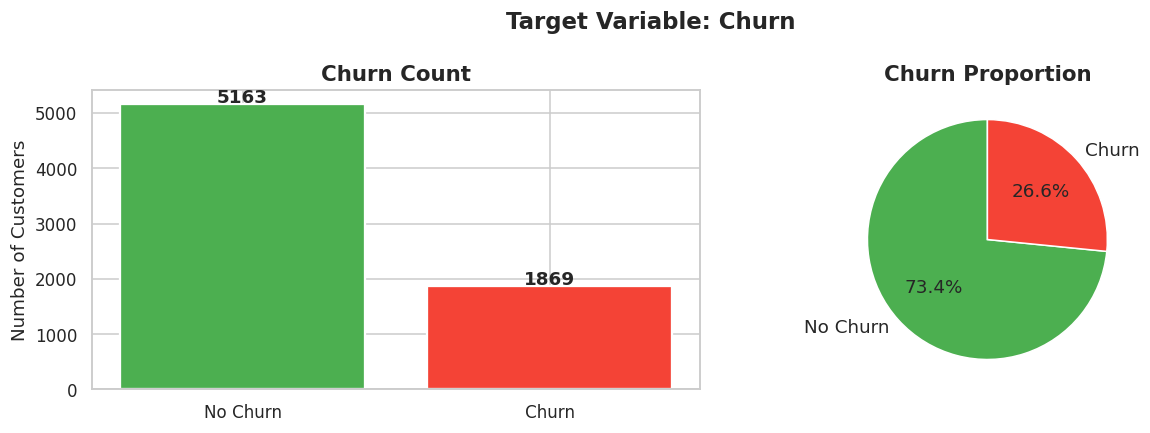

⚠️  Dataset is imbalanced — ~26% churn rate. F1-Score will be primary metric.


In [ ]:
# ─Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Churn'].value_counts()
labels = ['No Churn', 'Churn']
colors = ['#4CAF50', '#F44336']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  Dataset is imbalanced — ~26% churn rate. F1-Score will be primary metric.')

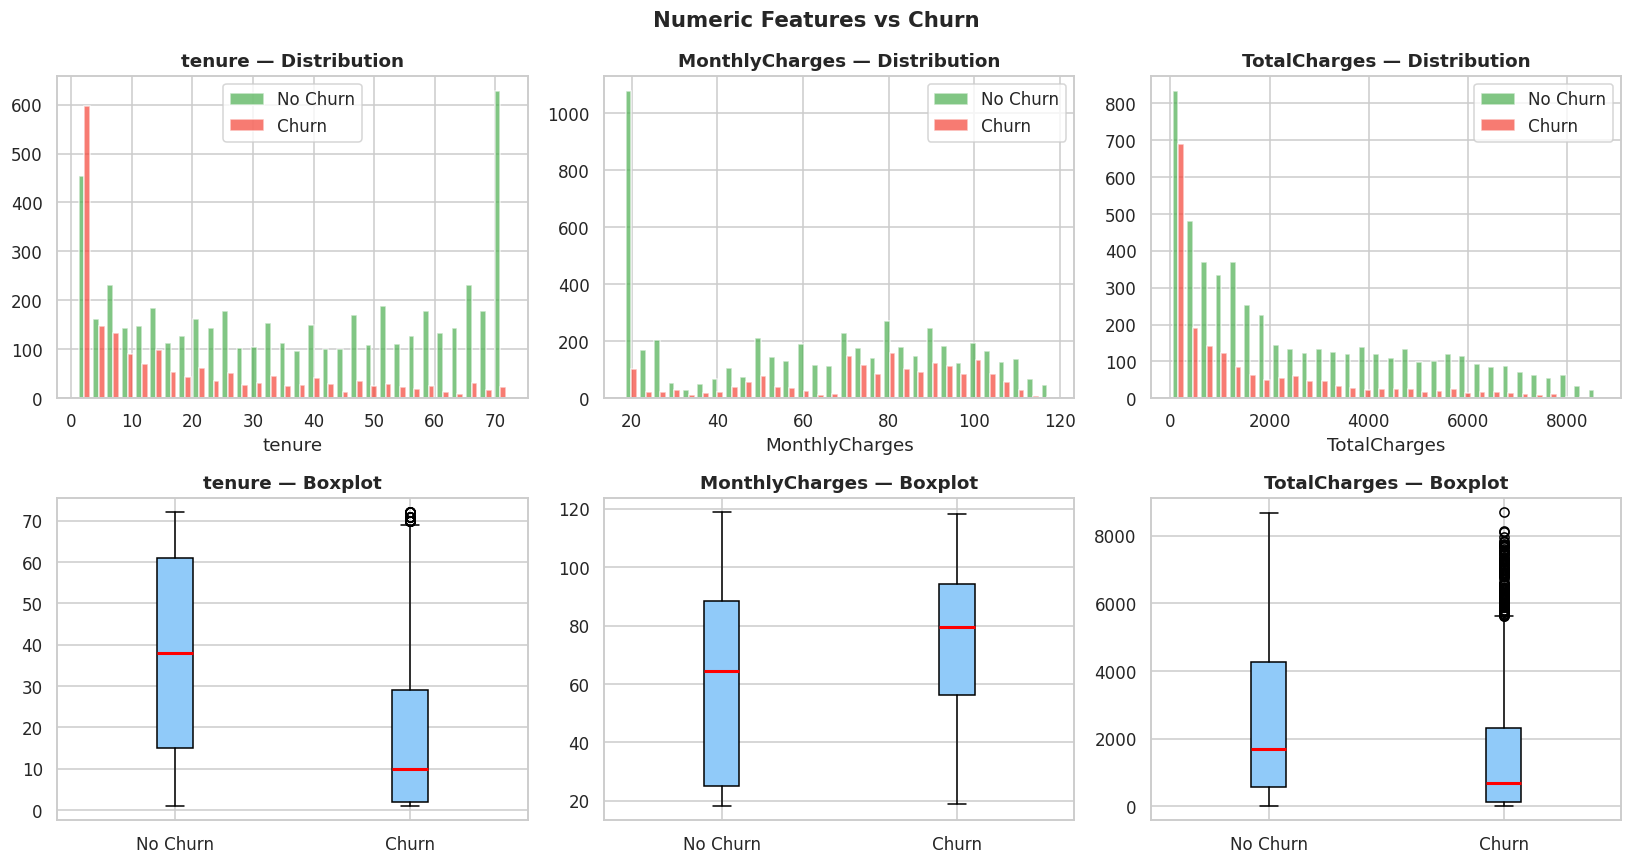

In [ ]:
# Numeric Feature Distributions
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(
        [df[df['Churn']==0][col], df[df['Churn']==1][col]],
        bins=30, label=['No Churn', 'Churn'],
        color=['#4CAF50', '#F44336'], alpha=0.7
    )
    axes[0, i].set_title(f'{col} — Distribution', fontweight='bold')
    axes[0, i].legend()
    axes[0, i].set_xlabel(col)

    # Box plot
    bp_data = [df[df['Churn']==0][col], df[df['Churn']==1][col]]
    bp = axes[1, i].boxplot(bp_data, labels=['No Churn', 'Churn'],
                             patch_artist=True,
                             boxprops=dict(facecolor='#90CAF9'),
                             medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} — Boxplot', fontweight='bold')

plt.suptitle('Numeric Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

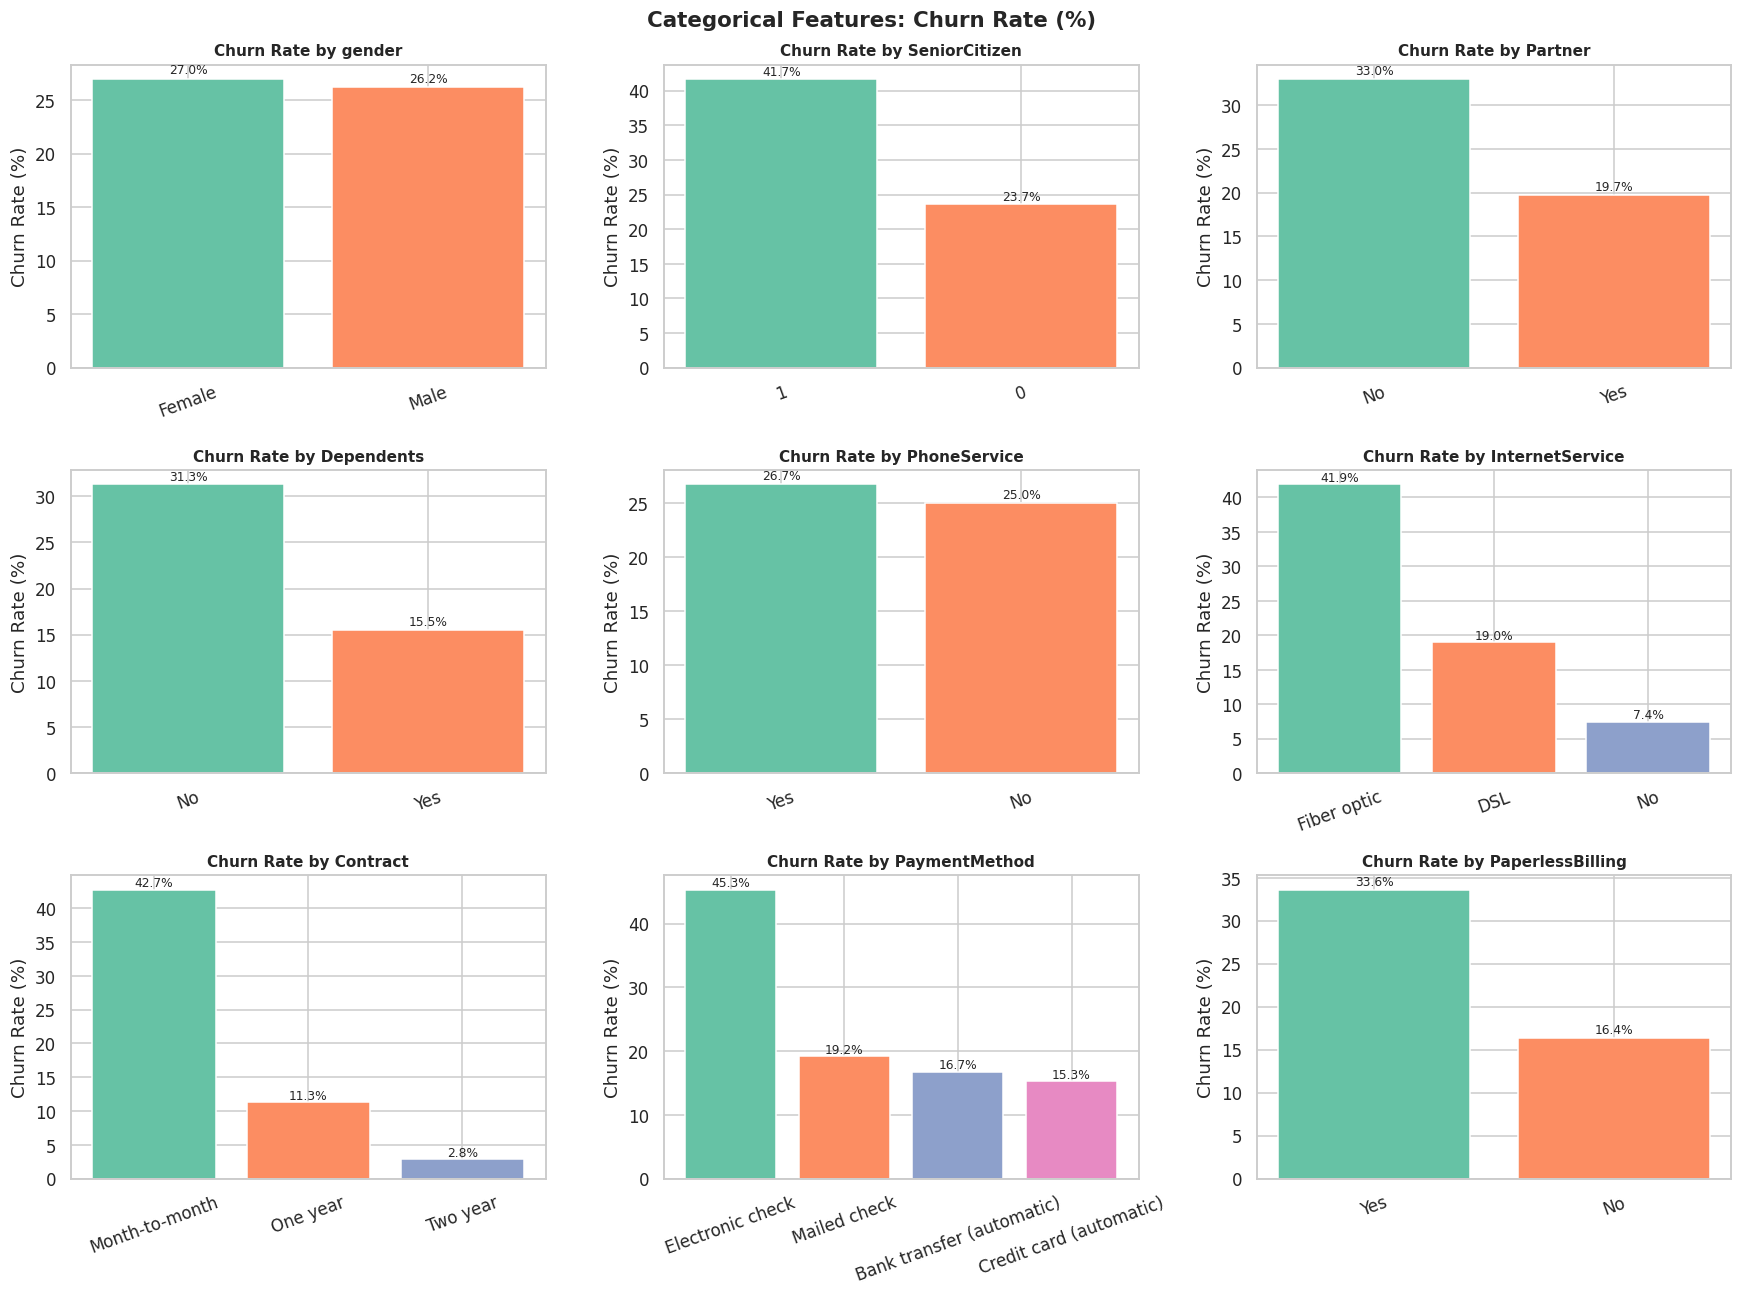

In [ ]:
# Categorical Features vs Churn
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values * 100,
                        color=sns.color_palette('Set2', len(churn_rate)),
                        edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                     f'{h:.1f}%', ha='center', fontsize=8)

plt.suptitle('Categorical Features: Churn Rate (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

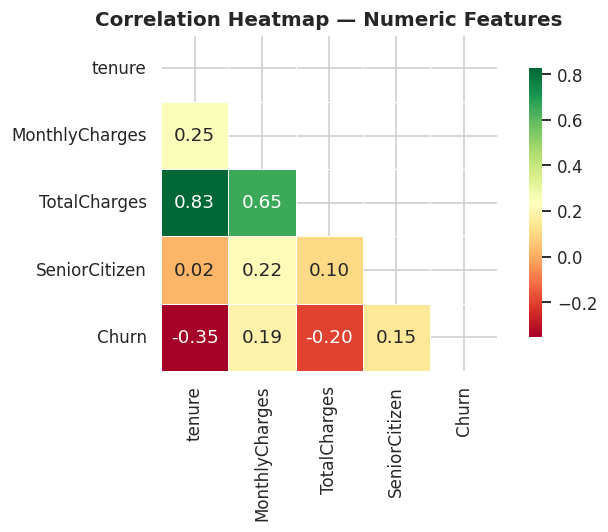

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(7, 5))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

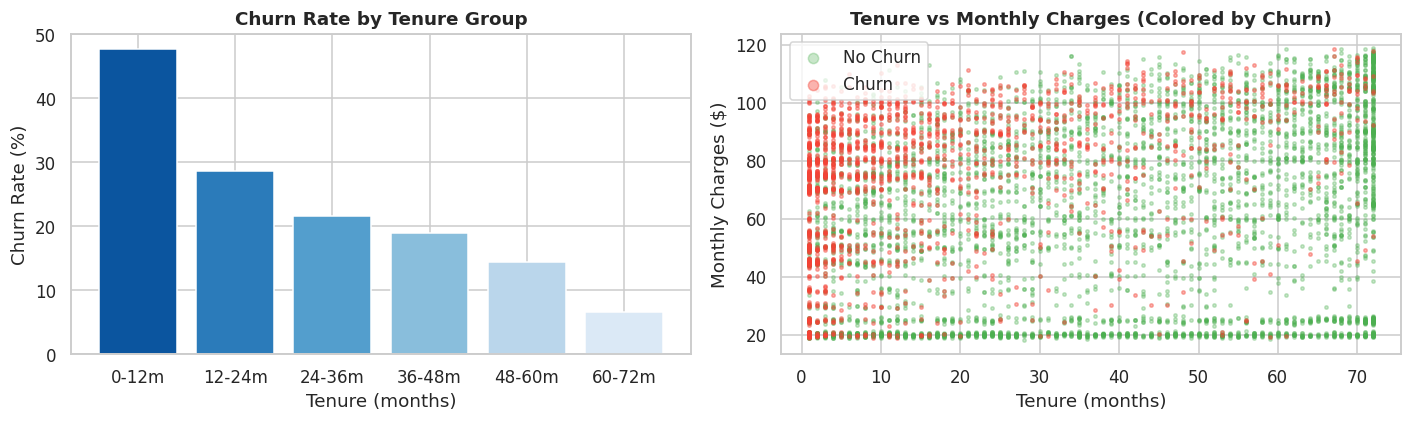

In [ ]:
# Key Insight: Tenure vs Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tenure bins
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                           labels=['0-12m','12-24m','24-36m','36-48m','48-60m','60-72m'])
churn_by_tenure = df.groupby('tenure_bin')['Churn'].mean() * 100
axes[0].bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
             color=sns.color_palette('Blues_r', 6))
axes[0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure (months)')

# Monthly Charges vs Churn
axes[1].scatter(df[df['Churn']==0]['tenure'], df[df['Churn']==0]['MonthlyCharges'],
                alpha=0.3, s=5, color='#4CAF50', label='No Churn')
axes[1].scatter(df[df['Churn']==1]['tenure'], df[df['Churn']==1]['MonthlyCharges'],
                alpha=0.4, s=5, color='#F44336', label='Churn')
axes[1].set_title('Tenure vs Monthly Charges (Colored by Churn)', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()
df.drop(columns=['tenure_bin'], inplace=True)

**📝 Key Insights:**
1. **Short tenure customers churn most** — new customers in the first year have the highest churn risk (~47%).
2. **Month-to-Month contracts** have dramatically higher churn (~43%) vs Two-Year contracts (~3%).
3. **Higher Monthly Charges** correlate with more churn.
4. **Fiber Optic internet** users churn more than DSL users.
5. Dataset is **imbalanced** — 73.5% stay, 26.5% churn.

---
## 4️⃣ Data Preprocessing

In [ ]:
binary_cols = [c for c in df.columns
               if df[c].dtype == 'object' and df[c].nunique() == 2]
multi_cols  = [c for c in df.columns
               if df[c].dtype == 'object' and df[c].nunique() > 2]

print('Binary (Label Encode):', binary_cols)
print('Multi-value (One-Hot):', multi_cols)

Binary (Label Encode): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-value (One-Hot): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [ ]:
df_enc = df.copy()

le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)

print(f'Shape after encoding: {df_enc.shape}')
print(f'Feature columns: {df_enc.shape[1] - 1}')
df_enc.head(3)

Shape after encoding: (7032, 31)
Feature columns: 30


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# split
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features (X): (7032, 30)
Target  (y): (7032,)
Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


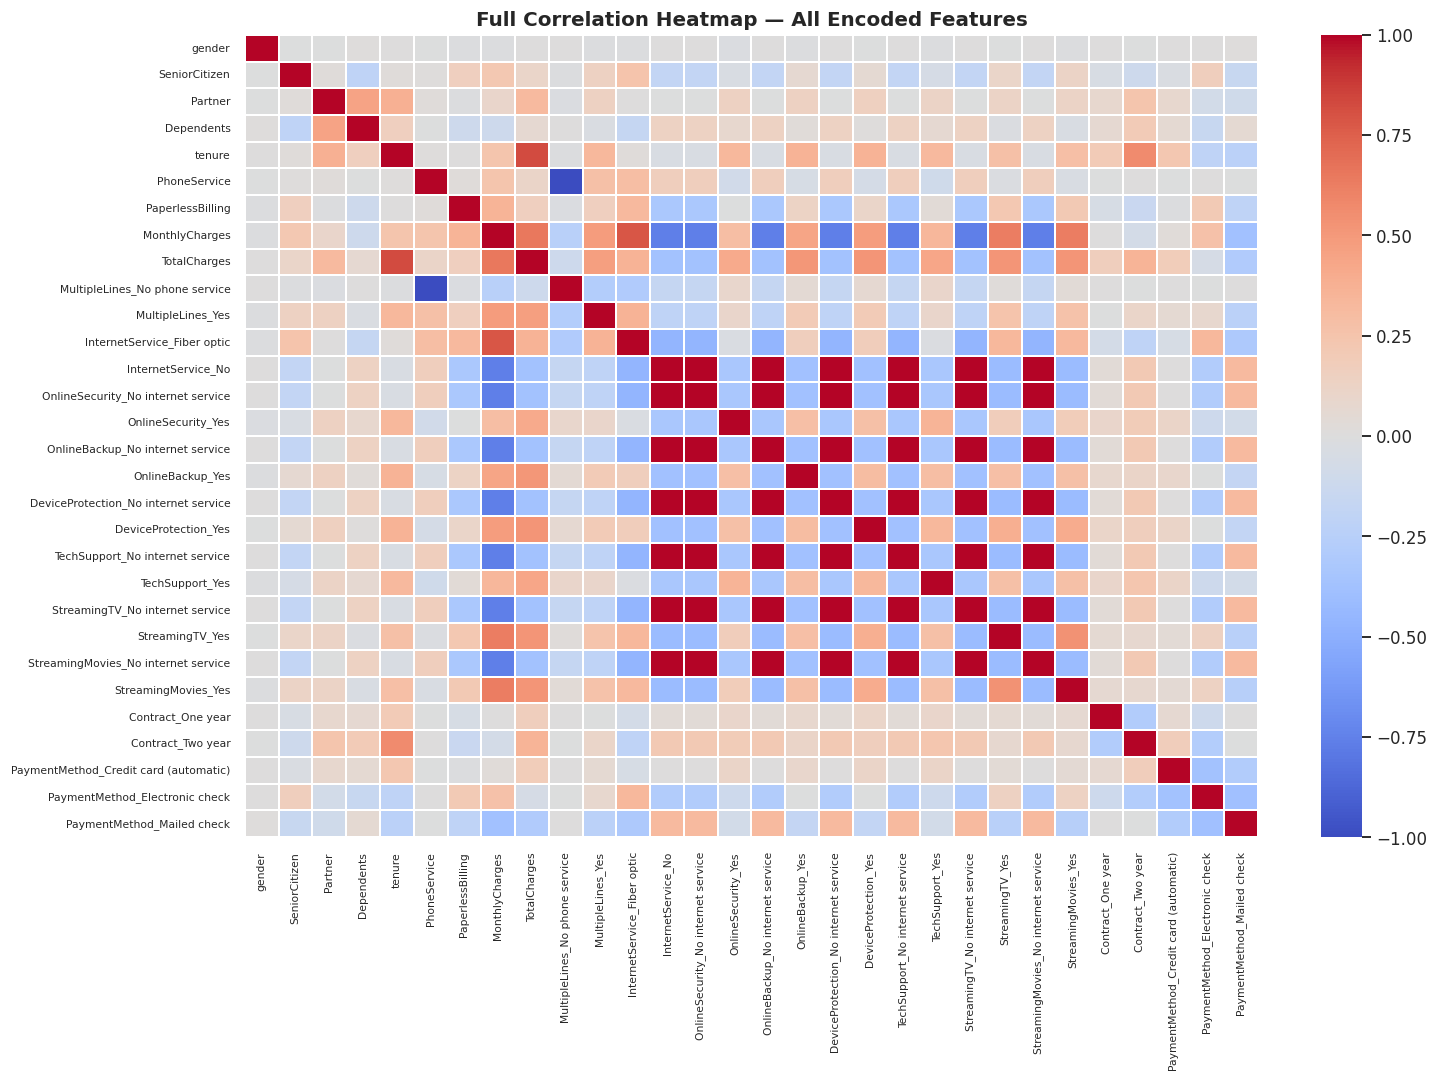

In [ ]:
corr_all = X.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_all, cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True)
plt.title('Full Correlation Heatmap — All Encoded Features', fontsize=13, fontweight='bold')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

---
##  5️⃣ Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} rows ({100*len(X_train)/len(X):.0f}%)')
print(f'Test set       : {X_test.shape[0]:,} rows ({100*len(X_test)/len(X):.0f}%)')
print(f'\nChurn rate (train): {y_train.mean():.3f}')
print(f'Churn rate (test) : {y_test.mean():.3f}')


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nScaling complete.')

Training set   : 5,625 rows (80%)
Test set       : 1,407 rows (20%)

Churn rate (train): 0.266
Churn rate (test) : 0.266

Scaling complete.


---
## 6️⃣ Model Building — Machine Learning



In [ ]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_sc, y_train)
lr_pred  = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Churn','Churn']))

=== Logistic Regression ===
Accuracy : 0.7264
F1 Score : 0.6075
ROC-AUC  : 0.8350

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1033
       Churn       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Churn','Churn']))

=== Random Forest ===
Accuracy : 0.7918
F1 Score : 0.5594
ROC-AUC  : 0.8227

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



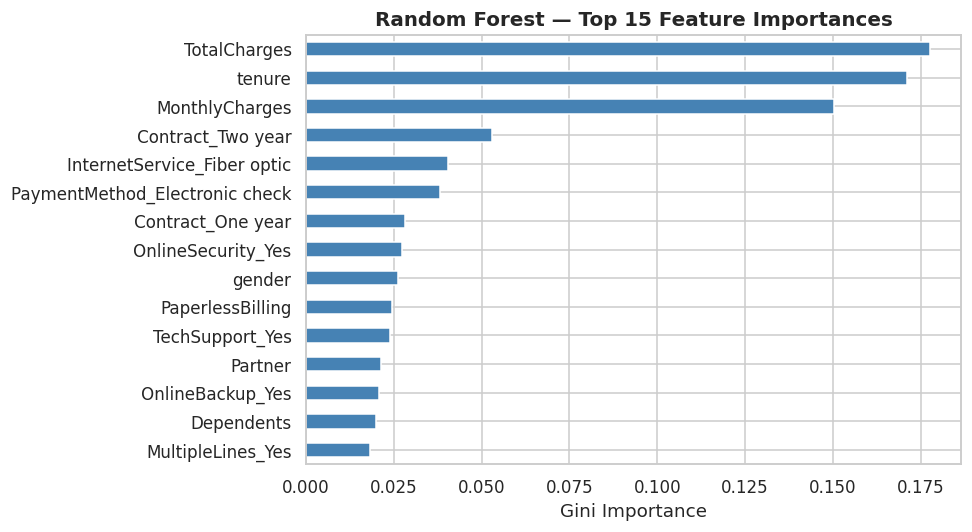

In [ ]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(9, 5))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(f'Accuracy : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, xgb_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['No Churn','Churn']))

=== XGBoost ===
Accuracy : 0.7328
F1 Score : 0.6100
ROC-AUC  : 0.8344

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



---
## 7️⃣ Model Evaluation — Visualizations

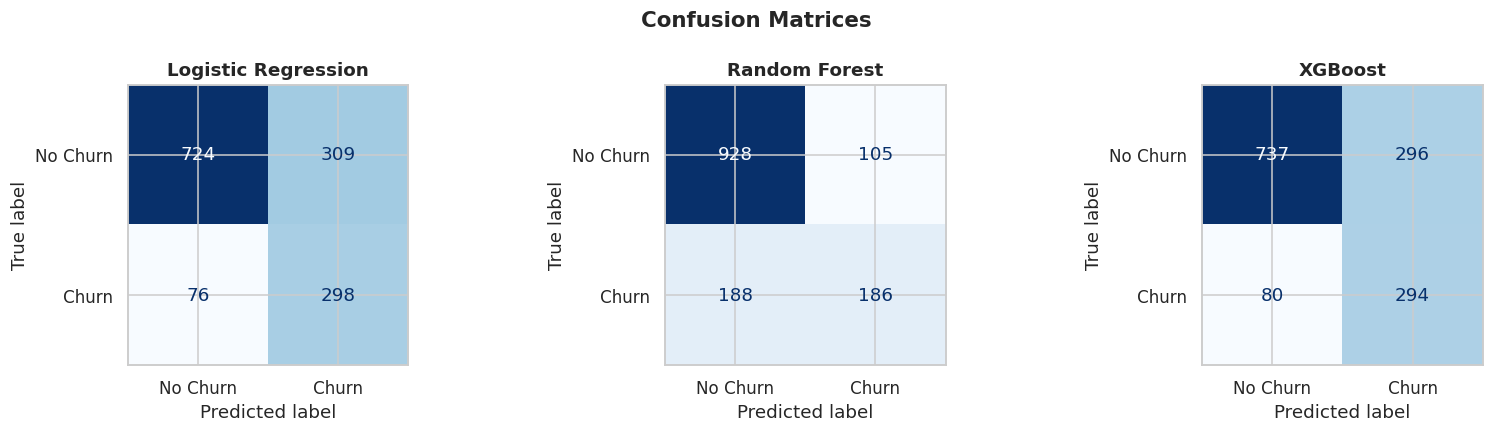

In [ ]:
models_info = [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest',       rf_pred, rf_proba),
    ('XGBoost',             xgb_pred, xgb_proba),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred, _) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

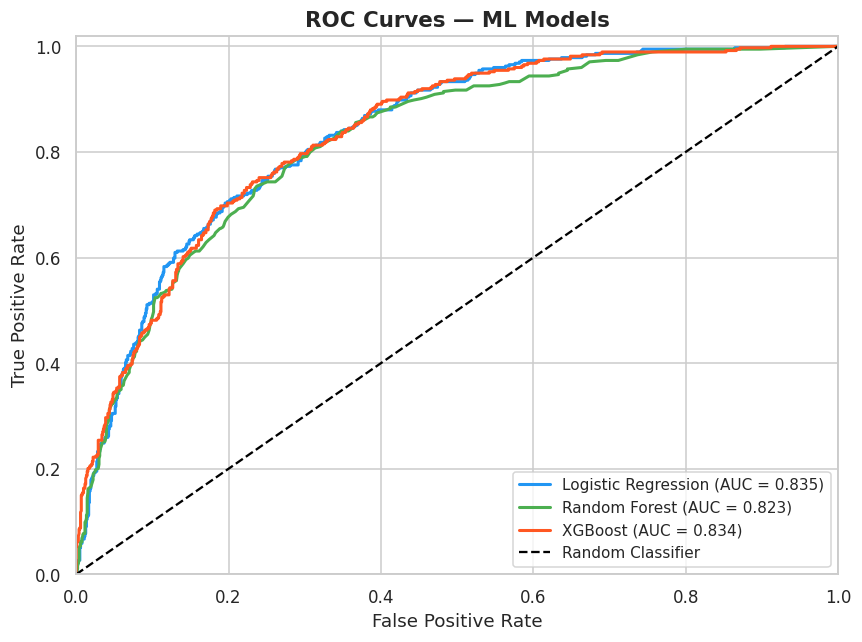

In [ ]:
# ROC Curves
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, _, proba), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — ML Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


=== ML Models Comparison ===
                     Accuracy  F1 Score  ROC-AUC
Model                                           
Logistic Regression    0.7264    0.6075   0.8350
Random Forest          0.7918    0.5594   0.8227
XGBoost                0.7328    0.6100   0.8344


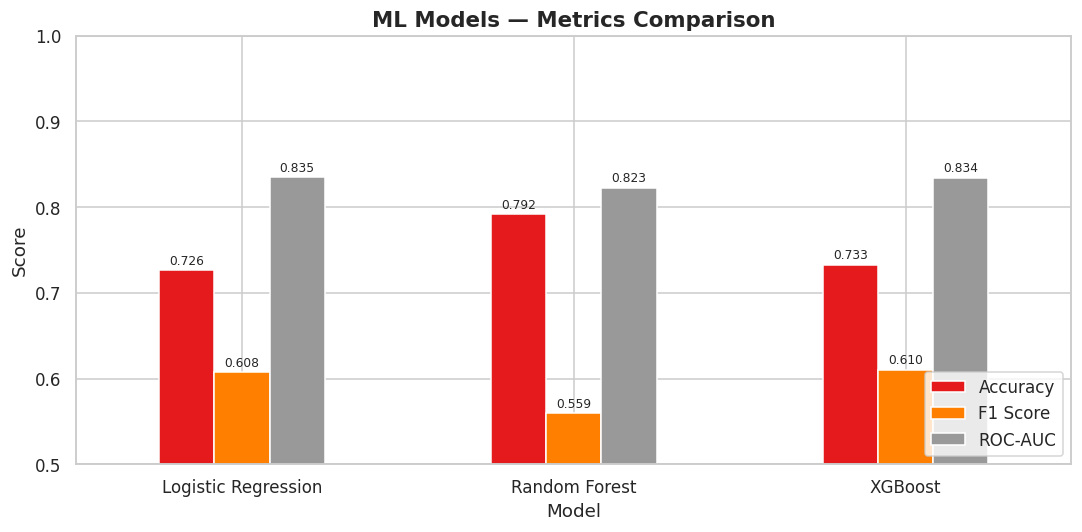

In [ ]:
# Metrics comparison bar chart
metrics_data = {
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, lr_pred),
                 accuracy_score(y_test, rf_pred),
                 accuracy_score(y_test, xgb_pred)],
    'F1 Score': [f1_score(y_test, lr_pred),
                 f1_score(y_test, rf_pred),
                 f1_score(y_test, xgb_pred)],
    'ROC-AUC':  [roc_auc_score(y_test, lr_proba),
                 roc_auc_score(y_test, rf_proba),
                 roc_auc_score(y_test, xgb_proba)],
}
metrics_df = pd.DataFrame(metrics_data).set_index('Model')
print('\n=== ML Models Comparison ===')
print(metrics_df.round(4))

ax = metrics_df.plot(kind='bar', figsize=(10, 5), colormap='Set1',
                      edgecolor='white', rot=0)
ax.set_title('ML Models — Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

---
##  8️⃣ Model Optimization — Hyperparameter Tuning

In [ ]:
# RandomizedSearchCV on Random Forest

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(f'\nBest CV F1 Score : {rf_random.best_score_:.4f}')
print(f'Best Parameters    : {rf_random.best_params_}')
# best_rf = rf_random.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV F1 Score : 0.5781
Best Parameters    : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 50}


In [ ]:
# Evaluate tuned Random forest
best_rf = rf_random.best_estimator_
best_rf_pred  = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

print('=== Tuned Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, best_rf_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, best_rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, best_rf_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_rf_pred, target_names=['No Churn','Churn']))

=== Tuned Random Forest ===
Accuracy : 0.7974
F1 Score : 0.5714
ROC-AUC  : 0.8375

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [ ]:
# RandomizedSearchCV on XGBoost (best ML model)
param_dist = {
    'n_estimators'  : [100, 200, 300, 400],
    'max_depth'     : [3, 4, 5, 6],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

rs = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=25,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rs.fit(X_train, y_train)

print(f'\nBest CV F1 Score : {rs.best_score_:.4f}')
print(f'Best Parameters    : {rs.best_params_}')


Best CV F1 Score : 0.6368
Best Parameters    : {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
# Evaluate tuned XGBoost
best_xgb = rs.best_estimator_
best_xgb_pred  = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

print('=== Tuned XGBoost ===')
print(f'Accuracy : {accuracy_score(y_test, best_xgb_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, best_xgb_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, best_xgb_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, best_xgb_pred, target_names=['No Churn','Churn']))

=== Tuned XGBoost ===
Accuracy : 0.7363
F1 Score : 0.6234
ROC-AUC  : 0.8424

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      0.71      0.80      1033
       Churn       0.50      0.82      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.75      1407



In [ ]:
# Feature Selection
importances_xgb = pd.Series(best_xgb.feature_importances_, index=X.columns)
selected_features = importances_xgb[importances_xgb > 0.005].index.tolist()

print(f'Features before selection : {X.shape[1]}')
print(f'Features after  selection : {len(selected_features)}')
print(f'Dropped : {X.shape[1] - len(selected_features)}')

# Re-train best XGBoost on selected features
best_xgb.fit(X_train[selected_features], y_train)
fs_pred  = best_xgb.predict(X_test[selected_features])
fs_proba = best_xgb.predict_proba(X_test[selected_features])[:, 1]

print(f'\nAfter Feature Selection:')
print(f'F1 Score : {f1_score(y_test, fs_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, fs_proba):.4f}')

Features before selection : 30
Features after  selection : 28
Dropped : 2

After Feature Selection:
F1 Score : 0.6226
ROC-AUC  : 0.8415


---
## 9️⃣ Final ML Model Selection

                            Accuracy  F1 Score  ROC-AUC
Model                                                  
Logistic Regression           0.7264    0.6075   0.8350
Random Forest                 0.7918    0.5594   0.8227
Radnom Forest (tuned)         0.7328    0.6100   0.8344
XGBoost (base)                0.7363    0.6234   0.8424
XGBoost (tuned)               0.7363    0.6226   0.8415
XGBoost (tuned + feat sel)    0.7974    0.5714   0.8375


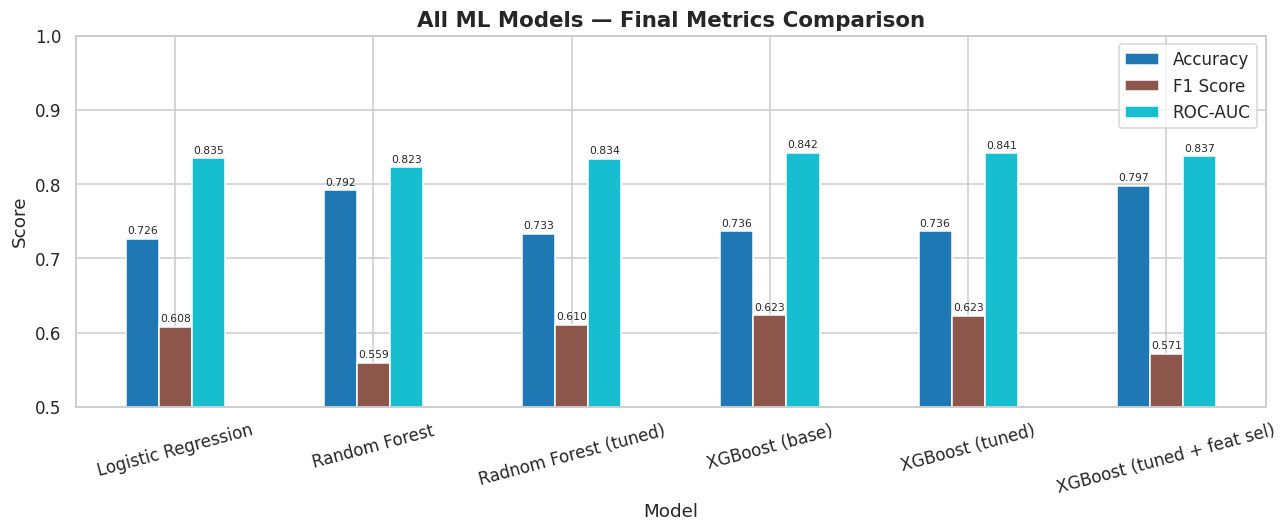

In [ ]:
# Final comparison table
final_ml = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest', 'Radnom Forest (tuned)', 'XGBoost (base)',
                 'XGBoost (tuned)', 'XGBoost (tuned + feat sel)',],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_xgb_pred),
        accuracy_score(y_test, fs_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, best_xgb_pred),
        f1_score(y_test, fs_pred),
        f1_score(y_test, best_rf_pred)
    ],
    'ROC-AUC' : [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, best_xgb_proba),
        roc_auc_score(y_test, fs_proba),
        roc_auc_score(y_test, best_rf_proba)
    ]
}).set_index('Model')

print(final_ml.round(4).to_string())

ax = final_ml.plot(kind='bar', figsize=(12, 5), colormap='tab10',
                    edgecolor='white', rot=15)
ax.set_title('All ML Models — Final Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Deep Learning — Artificial Neural Network (ANN)

### Architecture Design

In [ ]:
# Build ANN
def build_ann(input_dim, learning_rate=0.001):
    """
    ANN Architecture:
      Input  → Dense(128, relu) → Dropout(0.3)
             → Dense(64,  relu) → Dropout(0.3)
             → Dense(32,  relu) → Dropout(0.2)
             → Dense(1,   sigmoid)   ← binary output
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu',
                     kernel_initializer='he_normal'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

ann = build_ann(X_train_sc.shape[1])
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train.values)
class_weights = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weights}')

Class weights: {0: np.float64(0.6809927360774818), 1: np.float64(1.8812709030100334)}


In [ ]:
# Train ANN
tf.random.set_seed(42)
np.random.seed(42)

early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=15, restore_best_weights=True, mode='max'
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0
)

history = ann.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6513 - auc: 0.7001 - loss: 0.6949 - precision: 0.4067 - recall: 0.6565 - val_accuracy: 0.7334 - val_auc: 0.8117 - val_loss: 0.5333 - val_precision: 0.4830 - val_recall: 0.7290 - learning_rate: 0.0010
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7118 - auc: 0.7900 - loss: 0.5724 - precision: 0.4760 - recall: 0.7494 - val_accuracy: 0.7216 - val_auc: 0.8341 - val_loss: 0.5384 - val_precision: 0.4712 - val_recall: 0.8037 - learning_rate: 0.0010
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7189 - auc: 0.8041 - loss: 0.5485 - precision: 0.4843 - recall: 0.7580 - val_accuracy: 0.7251 - val_auc: 0.8380 - val_loss: 0.5355 - val_precision: 0.4755 - val_recall: 0.8178 - learning_rate: 0.0010
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7235 - auc: 0.8099 - loss: 0.5411 - precision: 0.4895 - recall: 0.7486 - val_accuracy: 0.7109 - val_auc: 0.8383 - val_loss: 0.5485 - val_pr

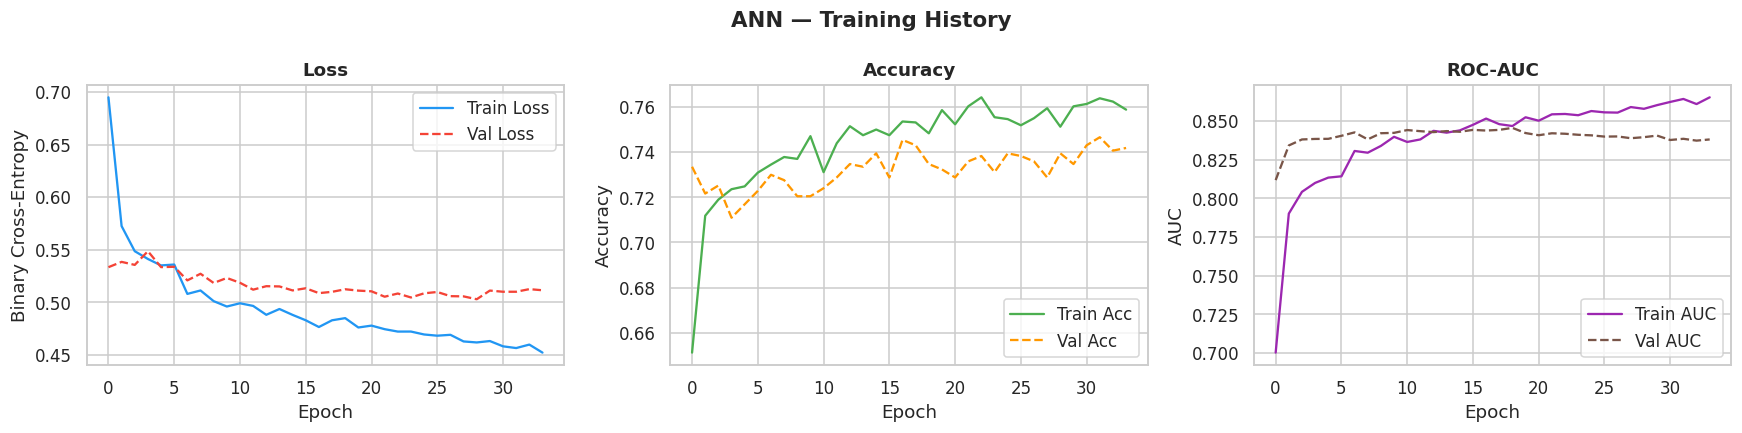

In [ ]:
# ── 11.4  Training History Plots ──────────────────────────────────────────────
hist = history.history

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(hist['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(hist['val_loss'], label='Val Loss',   color='#F44336', linestyle='--')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')

# Accuracy
axes[1].plot(hist['accuracy'],     label='Train Acc', color='#4CAF50')
axes[1].plot(hist['val_accuracy'], label='Val Acc',   color='#FF9800', linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

# AUC
axes[2].plot(hist['auc'],     label='Train AUC', color='#9C27B0')
axes[2].plot(hist['val_auc'], label='Val AUC',   color='#795548', linestyle='--')
axes[2].set_title('ROC-AUC', fontweight='bold'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')

plt.suptitle('ANN — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate ANN
ann_proba = ann.predict(X_test_sc, verbose=0).flatten()

# Optimal threshold using Youden's J statistic
from sklearn.metrics import roc_curve
fpr_ann, tpr_ann, thresholds = roc_curve(y_test, ann_proba)
j_scores = tpr_ann - fpr_ann
best_thresh = thresholds[np.argmax(j_scores)]
print(f'Optimal threshold (Youden): {best_thresh:.3f}')

ann_pred = (ann_proba >= best_thresh).astype(int)

print('\n=== ANN Results ===')
print(f'Accuracy : {accuracy_score(y_test, ann_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, ann_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, ann_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, ann_pred, target_names=['No Churn','Churn']))

Optimal threshold (Youden): 0.496

=== ANN Results ===
Accuracy : 0.7143
F1 Score : 0.6089
ROC-AUC  : 0.8302

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.77      1033
       Churn       0.48      0.84      0.61       374

    accuracy                           0.71      1407
   macro avg       0.70      0.75      0.69      1407
weighted avg       0.80      0.71      0.73      1407



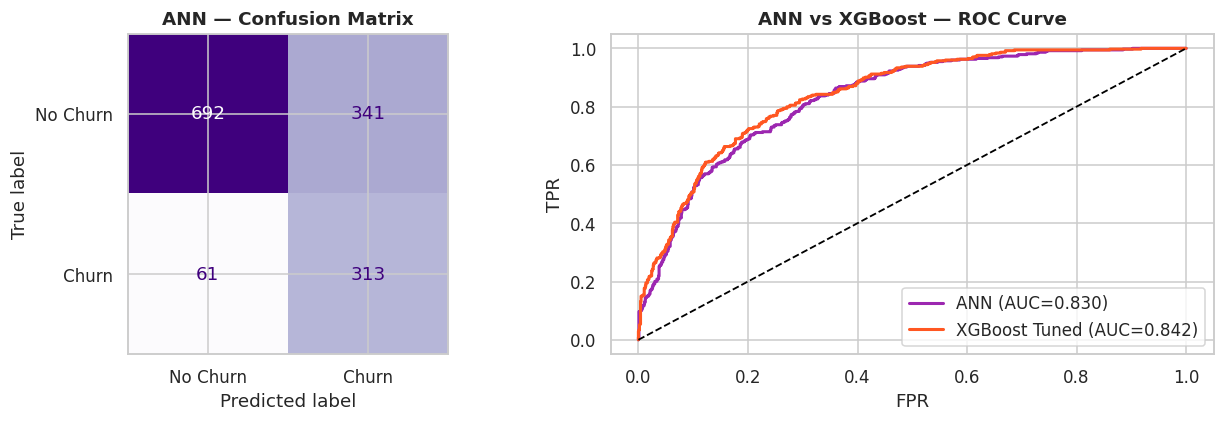

In [ ]:
# ANN confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_ann = confusion_matrix(y_test, ann_pred)
ConfusionMatrixDisplay(cm_ann, display_labels=['No Churn','Churn']).plot(
    ax=axes[0], cmap='Purples', colorbar=False)
axes[0].set_title('ANN — Confusion Matrix', fontweight='bold')

# ROC comparison with best ML model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb_proba)
axes[1].plot(fpr_ann, tpr_ann, color='#9C27B0', lw=2,
             label=f'ANN (AUC={roc_auc_score(y_test,ann_proba):.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, color='#FF5722', lw=2,
             label=f'XGBoost Tuned (AUC={roc_auc_score(y_test,best_xgb_proba):.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.2)
axes[1].set_title('ANN vs XGBoost — ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 1️⃣2️⃣ Final Comparison — ML vs Deep Learning

In [ ]:
# ── Final comparison table (all models) ───────────────────────────────────────
all_models = pd.DataFrame({
    'Model'   : ['Logistic Regression', 'Random Forest', 'Random Forest (tuned)',
                 'XGBoost (base)', 'XGBoost (tuned)',
                 'ANN (Deep Learning)'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_xgb_pred),
        accuracy_score(y_test, ann_pred),

    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, best_rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, best_xgb_pred),
        f1_score(y_test, ann_pred),

    ],
    'ROC-AUC' : [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, best_rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, best_xgb_proba),
        roc_auc_score(y_test, ann_proba),

    ],
    'Type'    : ['ML','ML','ML','ML','ML','DL']
})

print('\n' + '='*70)
print('           FINAL MODELS COMPARISON')
print('='*70)
print(all_models.set_index('Model')[['Accuracy','F1 Score','ROC-AUC']].round(4).to_string())
print('='*70)


           FINAL MODELS COMPARISON
                       Accuracy  F1 Score  ROC-AUC
Model                                             
Logistic Regression      0.7264    0.6075   0.8350
Random Forest            0.7918    0.5594   0.8227
Random Forest (tuned)    0.7974    0.5714   0.8375
XGBoost (base)           0.7328    0.6100   0.8344
XGBoost (tuned)          0.7363    0.6234   0.8424
ANN (Deep Learning)      0.7143    0.6089   0.8302


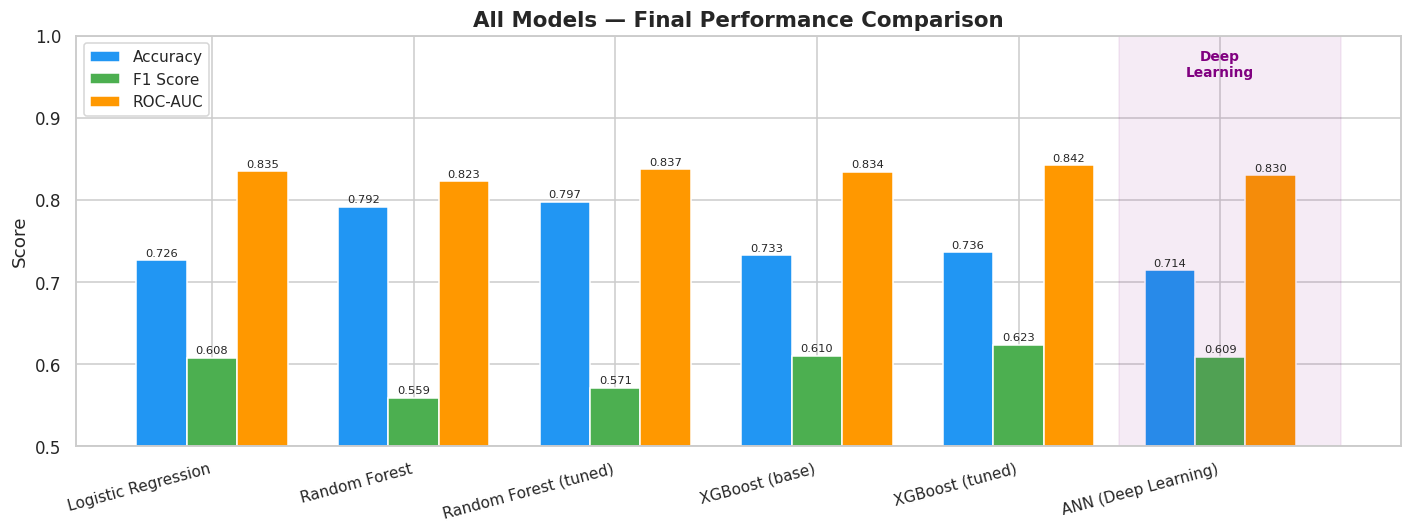

In [ ]:
# Final grouped bar chart
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(all_models))
width = 0.25

b1 = ax.bar(x - width, all_models['Accuracy'], width, label='Accuracy',  color='#2196F3', edgecolor='white')
b2 = ax.bar(x,          all_models['F1 Score'], width, label='F1 Score',  color='#4CAF50', edgecolor='white')
b3 = ax.bar(x + width,  all_models['ROC-AUC'],  width, label='ROC-AUC',   color='#FF9800', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_models['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — Final Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
for bar in [*b1, *b2, *b3]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=7.5)

# Shade the DL model bar region
ax.axvspan(4.5, 5.6, alpha=0.08, color='purple', label='Deep Learning')
ax.annotate('Deep\nLearning', xy=(5, 0.95), ha='center', color='purple',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
best_row = all_models.loc[all_models['F1 Score'].idxmax()]

print('\n' + '🏆 '*20)
print('   BEST MODEL Dependant on F1 Score')
print('🏆 '*20)
print(f'  Model     : {best_row["Model"]}')
print(f'  Accuracy  : {best_row["Accuracy"]:.4f}')
print(f'  F1 Score  : {best_row["F1 Score"]:.4f}')
print(f'  ROC-AUC   : {best_row["ROC-AUC"]:.4f}')
print(f'  Type      : {best_row["Type"]}')


🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 
   BEST MODEL SUMMARY
🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 🏆 
  Model     : XGBoost (tuned)
  Accuracy  : 0.7363
  F1 Score  : 0.6234
  ROC-AUC   : 0.8424
  Type      : ML
